# Scutellum Height Oscillation and Walking vs. Running

Companion to `Joint_Kinematics_Analysis.ipynb`. Tests whether *Drosophila* locomotion follows an inverted-pendulum (walking) or spring-mass (running) model by measuring the phase relationship between thorax height and forward-speed oscillations across the full speed range.


In [1]:
### Setup — paths, imports
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
from scipy import signal
from scipy.ndimage import uniform_filter1d, gaussian_filter1d
from scipy.signal import butter, filtfilt, hilbert
from scipy.stats import spearmanr, pearsonr, circmean, circstd
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Add 3d_tracking_dataset repo root so utils can be imported
_nb_dir = Path().resolve()
_repo_root = _nb_dir.parent if _nb_dir.name == 'notebooks' else _nb_dir
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))
import utils.io_dict_to_hdf5 as ioh5

# ── Edit these ────────────────────────────────────────────────────────────────
H5_PATH    = Path("/home/user/3D_tracking_paper/IK_outputs/walking_videos/free_walking/Data_analysis/analysis/ik_output_combined_v1_free_walking.h5")
OUTPUT_DIR = Path('/home/user/3D_tracking_paper/output/free_walking')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FPS           = 800          # Hz
LEGS          = ['T1_left', 'T1_right', 'T2_left', 'T2_right', 'T3_left', 'T3_right']
REFERENCE_LEG = 'T1_left'
HEADING_BODIES = ['thorax']
SCALE         = 10.0         # model units → mm


## Build df_valid from HDF5

Builds the per-frame DataFrame from the STAC IK output HDF5. Set `H5_PATH` in the Setup cell above, then run the next cell.

**Columns produced:**

| Column | Description |
|---|---|
| `bout_id` | HDF5 group key |
| `fly_id` | first token of `bout_id` split on `_` (edit `_parse_fly_id` if needed) |
| `frame` | 0-based frame index within bout |
| `thorax_z` | `xpos[:,1,2]` model units (Cell H1 multiplies by 10 → mm) |
| `forward_speed` | thorax XY displacement × FPS (mm/s) |
| `T1_left_phase` | linear phase in [−π, π] per T1L stride cycle; NaN outside complete cycles |
| `n_legs_stance` | legs in stance (0–6) per frame |
| `step_cycle_id` | integer cycle index from T1L swing onsets |
| `step_cycle_mean_speed` | mean forward_speed within each complete stride cycle |

**Site indices** (fruitfly_v1, verified from `fruitfly_v1_free.xml`):
`T1L=18, T1R=25, T2L=31, T2R=37, T3L=43, T3R=49` in `xpos_egocentric[:,idx,:]`

In [2]:
### Build df_valid — pipeline functions (mirrors Joint_Kinematics_Analysis)

# ── Data loading ──────────────────────────────────────────────────────────────
def load_ik_bouts(h5_path):
    d = ioh5.load(h5_path)
    bout_keys    = sorted(k for k in d if k.startswith('bout_'))
    fly_ids      = np.array(d['info']['fly_ids'])
    clip_lengths = np.array(d['info']['clip_lengths'])
    print(f"Loaded {len(bout_keys)} bouts | {len(np.unique(fly_ids))} unique flies")
    print(f"Frames/bout: min={clip_lengths.min()}, max={clip_lengths.max()}, "
          f"total={clip_lengths.sum():,}")
    return d, bout_keys, fly_ids, clip_lengths

_LEG_SHORT = {
    'T1_left':  'T1L', 'T1_right': 'T1R',
    'T2_left':  'T2L', 'T2_right': 'T2R',
    'T3_left':  'T3L', 'T3_right': 'T3R',
}

def find_leg_tip_site_indices(site_names, legs):
    indices = {}
    for leg in legs:
        short = _LEG_SHORT.get(leg, leg)
        patterns = [f"{short}_TaTip", f"{leg}_TaTip", f"claw_{leg}", f"{leg}_claw"]
        match = None
        for p in patterns:
            match = next((i for i, n in enumerate(site_names) if p in n), None)
            if match is not None:
                break
        indices[leg] = match
        if match is None:
            print(f"Warning: no tip site for {leg}")
    return indices

def bouts_to_dataframe(bout_dict, bout_keys, fly_ids, joint_list,
                       names_xpos, heading_bodies,
                       egocentric_site_names, leg_tip_site_indices):
    frames = []
    for bout_idx, (key, fly_id) in enumerate(zip(bout_keys, fly_ids)):
        b    = bout_dict[key]
        xpos = np.array(b['xpos'])
        T    = xpos.shape[0]
        row  = {
            'frame':    np.arange(T),
            'bout_idx': np.full(T, bout_idx, dtype=np.int32),
            'bout_id':  np.full(T, key, dtype=object),
            'fly_id':   np.full(T, fly_id, dtype=object),
        }
        if 'qpos' in b:
            qpos = np.array(b['qpos'])
            for leg, joint, idx in joint_list:
                row[f"{leg}_{joint}"] = qpos[:, idx]
        for body in heading_bodies:
            if body in names_xpos:
                bidx = names_xpos.index(body)
                row[f"{body}_x"] = xpos[:, bidx, 0]
                row[f"{body}_y"] = xpos[:, bidx, 1]
                row[f"{body}_z"] = xpos[:, bidx, 2]
        if 'xpos_egocentric' in b:
            xpos_ego = np.array(b['xpos_egocentric'])
            for leg, site_idx in leg_tip_site_indices.items():
                if site_idx is not None and site_idx < xpos_ego.shape[1]:
                    row[f"{leg}_tip_x_ego"] = xpos_ego[:, site_idx, 0]
                    row[f"{leg}_tip_y_ego"] = xpos_ego[:, site_idx, 1]
                    row[f"{leg}_tip_z_ego"] = xpos_ego[:, site_idx, 2]
        _CLAW_NAMES = {
            'T1_left': 'claw_T1_left', 'T1_right': 'claw_T1_right',
            'T2_left': 'claw_T2_left', 'T2_right': 'claw_T2_right',
            'T3_left': 'claw_T3_left', 'T3_right': 'claw_T3_right',
        }
        for leg, cname in _CLAW_NAMES.items():
            if cname in names_xpos:
                ci = names_xpos.index(cname)
                row[f"{leg}_tip_x_world"] = xpos[:, ci, 0]
                row[f"{leg}_tip_y_world"] = xpos[:, ci, 1]
                row[f"{leg}_tip_z_world"] = xpos[:, ci, 2]
        frames.append(pd.DataFrame(row))
    df = pd.concat(frames, ignore_index=True)
    print(f"Built DataFrame: {len(df):,} frames, {len(df.columns)} columns")
    return df

# ── Preprocessing ─────────────────────────────────────────────────────────────
def _gaussian_smooth(arr, sigma=4):
    mask = np.isnan(arr)
    out  = gaussian_filter1d(np.where(mask, 0., arr), sigma)
    cnt  = gaussian_filter1d((~mask).astype(float), sigma)
    out[cnt > 0] /= cnt[cnt > 0]
    out[mask]     = np.nan
    return out

def swing_onsets_from_stance(series):
    ss = series.values.astype(int)
    return np.where(np.diff(ss, prepend=ss[0]) == -1)[0]

def compute_swing_stance_tip_speed(df, legs, fps=800, thresh_frac=0.20):
    df = df.copy()
    for leg in legs:
        xcol, ycol, zcol = f"{leg}_tip_x_world", f"{leg}_tip_y_world", f"{leg}_tip_z_world"
        if zcol not in df.columns:
            continue
        ss = np.full(len(df), np.nan)
        for _bid, grp in df.groupby('bout_id', sort=False):
            idx = grp.index
            n   = len(grp)
            if n < 5:
                continue
            def _vel(col):
                v = grp[col].values.astype(float) if col in grp.columns else np.zeros(n)
                return np.gradient(v) * fps * 10
            spd = np.sqrt(_vel(xcol)**2 + _vel(ycol)**2 + _vel(zcol)**2)
            spd = _gaussian_smooth(spd, sigma=4)
            thr = thresh_frac * np.nanmax(spd)
            ss[idx] = (spd <= thr).astype(float)
        valid = ~np.isnan(ss)
        df.loc[valid, f"{leg}_swing_stance"] = ss[valid].astype(int)
    return df

def compute_n_legs_stance(df, legs):
    df = df.copy()
    cols = [f"{leg}_swing_stance" for leg in legs if f"{leg}_swing_stance" in df.columns]
    if cols:
        df['n_legs_stance'] = df[cols].sum(axis=1)
    return df

def compute_phases_from_swing(df, legs):
    df = df.copy()
    for leg in legs:
        ss_col = f"{leg}_swing_stance"
        if ss_col not in df.columns:
            continue
        phase_arr = np.full(len(df), np.nan)
        for _bid, grp in df.groupby('bout_id', sort=False):
            idx    = grp.index
            onsets = swing_onsets_from_stance(grp[ss_col])
            if len(onsets) < 2:
                continue
            phase = np.full(len(grp), np.nan)
            for i in range(len(onsets) - 1):
                t0, t1 = onsets[i], onsets[i + 1]
                phase[t0:t1] = np.linspace(-np.pi, np.pi, t1 - t0, endpoint=False)
            phase_arr[idx] = phase
        df[f"{leg}_phase"] = phase_arr
    return df

def compute_heading_and_velocity(df, fps=800, body='thorax', smooth_sigma=2):
    df = df.copy()
    x_col, y_col = f"{body}_x", f"{body}_y"
    if x_col not in df.columns or y_col not in df.columns:
        print(f"Warning: position columns not found for {body}")
        return df
    heading_arr   = np.full(len(df), np.nan)
    speed_arr     = np.full(len(df), np.nan)
    turn_rate_arr = np.full(len(df), np.nan)
    for bout_id, grp in df.groupby('bout_id'):
        idx = grp.index
        x   = gaussian_filter1d(grp[x_col].values.astype(float), sigma=smooth_sigma)
        y   = gaussian_filter1d(grp[y_col].values.astype(float), sigma=smooth_sigma)
        dx  = np.gradient(x) * fps
        dy  = np.gradient(y) * fps
        heading   = np.arctan2(dy, dx)
        heading_u = np.unwrap(heading)
        heading_s = gaussian_filter1d(heading_u, sigma=smooth_sigma)
        heading_s = (heading_s + np.pi) % (2 * np.pi) - np.pi
        heading_arr[idx]   = heading_s
        speed_arr[idx]     = np.sqrt(dx**2 + dy**2) * 10   # mm/s
        turn_rate_arr[idx] = np.gradient(heading_s) * fps
    df['heading']       = heading_arr
    df['forward_speed'] = speed_arr
    df['turning_rate']  = turn_rate_arr
    return df

def compute_step_cycle_speed(df, fps=800, ref_leg='T1_left'):
    df    = df.copy()
    ss_col  = f"{ref_leg}_swing_stance"
    spd_col = 'forward_speed'
    sc_id  = np.full(len(df), np.nan)
    sc_spd = np.full(len(df), np.nan)
    if ss_col not in df.columns:
        df['step_cycle_id']         = sc_id
        df['step_cycle_mean_speed'] = sc_spd
        return df
    for bout_id, grp in df.groupby('bout_id', sort=False):
        idx    = grp.index
        onsets = swing_onsets_from_stance(grp[ss_col])
        if len(onsets) < 2:
            continue
        spd = grp[spd_col].values.astype(float) if spd_col in grp.columns               else np.full(len(grp), np.nan)
        for k in range(len(onsets) - 1):
            t0, t1 = onsets[k], onsets[k + 1]
            sc_id[idx[t0:t1]]  = k
            sc_spd[idx[t0:t1]] = np.nanmean(spd[t0:t1])
    df['step_cycle_id']         = sc_id
    df['step_cycle_mean_speed'] = sc_spd
    return df

# ── Build df_valid ────────────────────────────────────────────────────────────
bout_dict, bout_keys, fly_ids, clip_lengths = load_ik_bouts(H5_PATH)
names_qpos            = list(bout_dict['info']['names_qpos'])
names_xpos            = list(bout_dict['info']['names_xpos'])
egocentric_site_names = list(bout_dict['info']['site_names_egocentric'])

leg_tip_site_indices = find_leg_tip_site_indices(egocentric_site_names, LEGS)
print(f"Leg tip site indices: {leg_tip_site_indices}")

# No joint angles needed for this analysis — pass empty joint_list
df = bouts_to_dataframe(
    bout_dict, bout_keys, fly_ids, joint_list=[],
    names_xpos=names_xpos,
    heading_bodies=HEADING_BODIES,
    egocentric_site_names=egocentric_site_names,
    leg_tip_site_indices=leg_tip_site_indices,
)

df = compute_swing_stance_tip_speed(df, LEGS, fps=FPS)
df = compute_n_legs_stance(df, LEGS)
df = compute_phases_from_swing(df, LEGS)
df = compute_heading_and_velocity(df, fps=FPS, body=HEADING_BODIES[0])
df = compute_step_cycle_speed(df, fps=FPS, ref_leg=REFERENCE_LEG)

# thorax_z is in model metres; * SCALE gives mm  (SCALE=10 → mm)
df_valid = df.copy()
print(f"\ndf_valid: {len(df_valid):,} rows | "
      f"{df_valid['bout_id'].nunique()} bouts | "
      f"{df_valid['fly_id'].nunique()} flies")
print(f"  thorax_z:              mean={df_valid['thorax_z'].mean():.4f} model-m  "
      f"({df_valid['thorax_z'].mean()*SCALE:.3f} mm)")
print(f"  forward_speed (mm/s):  {df_valid['forward_speed'].mean():.1f} ± "
      f"{df_valid['forward_speed'].std():.1f}")
print(f"  T1_left_phase valid:   "
      f"{df_valid['T1_left_phase'].notna().mean()*100:.1f}% of frames")
print(f"  step_cycle_mean_speed: "
      f"{df_valid['step_cycle_mean_speed'].notna().mean()*100:.1f}% of frames")


Loaded 198 bouts | 7 unique flies
Frames/bout: min=151, max=1271, total=78,633
Leg tip site indices: {'T1_left': 18, 'T1_right': 25, 'T2_left': 31, 'T2_right': 37, 'T3_left': 43, 'T3_right': 49}
Built DataFrame: 78,633 frames, 43 columns

df_valid: 78,633 rows | 198 bouts | 7 flies
  thorax_z:              mean=0.2024 model-m  (2.024 mm)
  forward_speed (mm/s):  18.8 ± 10.2
  T1_left_phase valid:   76.4% of frames
  step_cycle_mean_speed: 76.4% of frames


In [3]:
### Cell H1 — Add detrended thorax height to df_valid

df_valid['thorax_z_mm'] = df_valid['thorax_z'] * 10.0   # model-m → mm

BASELINE_FRAMES = int(0.100 * FPS)   # 400 frames — 500 ms rolling window

df_valid['thorax_z_baseline']  = np.nan
df_valid['thorax_z_detrended'] = np.nan

for bid, grp in df_valid.groupby('bout_id', sort=False):
    idx      = grp.index
    z_mm     = grp['thorax_z_mm'].values
    baseline = uniform_filter1d(z_mm, size=BASELINE_FRAMES, mode='nearest')
    df_valid.loc[idx, 'thorax_z_baseline']  = baseline
    df_valid.loc[idx, 'thorax_z_detrended'] = z_mm - baseline

# Bandpass oscillatory component (5–50 Hz — stride frequency band at 800 Hz)
b_bp, a_bp = butter(3, [5 / (FPS / 2), 50 / (FPS / 2)], btype='band')

df_valid['thorax_z_osc'] = np.nan
for bid, grp in df_valid.groupby('bout_id', sort=False):
    idx = grp.index
    if len(idx) < 30:
        continue
    df_valid.loc[idx, 'thorax_z_osc'] = filtfilt(b_bp, a_bp, grp['thorax_z_mm'].values)

print(f"thorax_z_mm:        mean={df_valid['thorax_z_mm'].mean():.3f} mm  "
      f"std={df_valid['thorax_z_mm'].std():.3f} mm")
print(f"thorax_z_detrended: mean≈0  std={df_valid['thorax_z_detrended'].std():.4f} mm")
print(f"thorax_z_osc:       mean≈0  std={df_valid['thorax_z_osc'].std():.4f} mm")

thorax_z_mm:        mean=2.024 mm  std=0.115 mm
thorax_z_detrended: mean≈0  std=0.0260 mm
thorax_z_osc:       mean≈0  std=0.0263 mm


Mean touchdown phase: 0.045 rad  (2.6°)


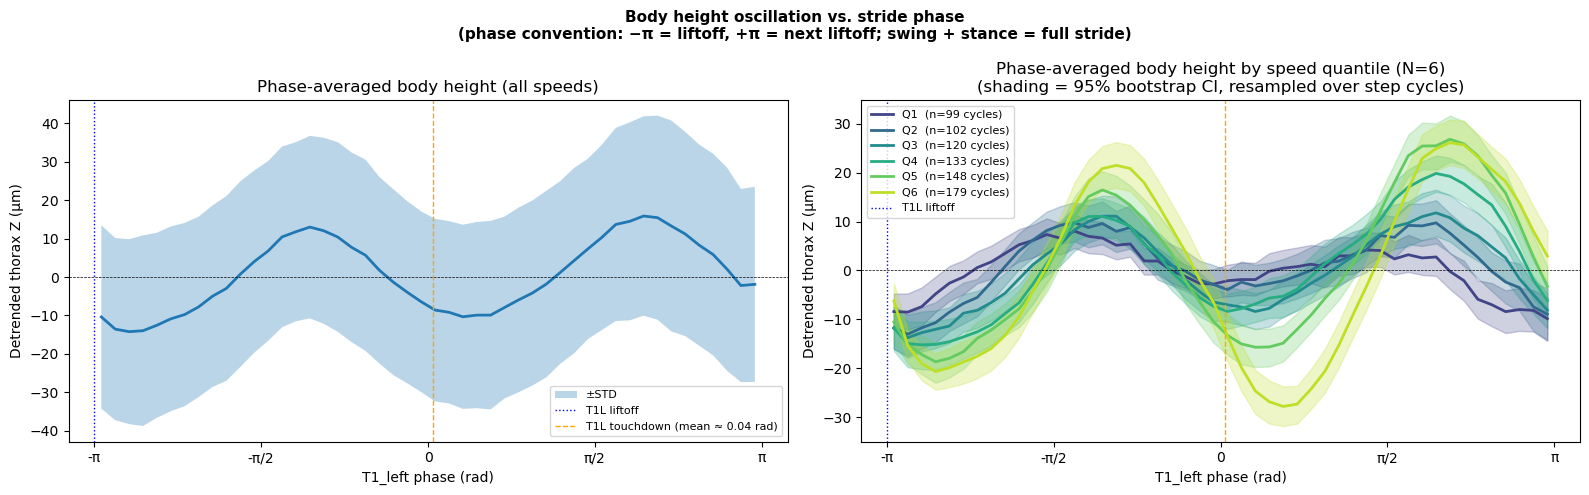

In [4]:
### Cell H2 — Phase-averaged height oscillation

N_BINS      = 48
N_QUANTILES = 6   # ← change this: 3=terciles, 4=quartiles, 5=quintiles, etc.

phase_bins  = np.linspace(-np.pi, np.pi, N_BINS + 1)
bin_centers = 0.5 * (phase_bins[:-1] + phase_bins[1:])
bin_idx     = np.clip(np.digitize(df_valid['T1_left_phase'], phase_bins) - 1, 0, N_BINS - 1)

# Dynamic labels
_q_labels = [f'Q{i+1}' for i in range(N_QUANTILES)]
if N_QUANTILES == 3:
    _q_labels = ['slow', 'medium', 'fast']
elif N_QUANTILES == 4:
    _q_labels = ['slow', 'med-slow', 'med-fast', 'fast']

speed_quantiles  = pd.qcut(df_valid['step_cycle_mean_speed'], q=N_QUANTILES,
                            labels=_q_labels)
df_valid['_sq'] = speed_quantiles

# Mean speed per quantile (used later for peak analysis)
_mean_speed_per_q = (df_valid.groupby('_sq', observed=True)['step_cycle_mean_speed']
                     .mean().to_dict())

# Compute mean touchdown phase (swing→stance transition) from T1_left data
_td_phases_list = []
for _bid, _grp in df_valid.groupby('bout_id', sort=False):
    if 'T1_left_swing_stance' not in _grp.columns:
        continue
    _ss = _grp['T1_left_swing_stance'].values.astype(int)
    _ph = _grp['T1_left_phase'].values
    _td_frames = np.where(np.diff(_ss, prepend=_ss[0]) == 1)[0]
    for _tf in _td_frames:
        if _tf < len(_ph) and not np.isnan(_ph[_tf]):
            _td_phases_list.append(_ph[_tf])

mean_td_phase = circmean(_td_phases_list, high=np.pi, low=-np.pi) if _td_phases_list else None
print(f"Mean touchdown phase: {mean_td_phase:.3f} rad  ({np.degrees(mean_td_phase):.1f}°)" if mean_td_phase is not None else "No touchdown phase computed")

z_vals = df_valid['thorax_z_detrended'].values * 1000   # mm → µm

# ── Bootstrap helper (resamples step cycles) ─────────────────────────────────
def _bootstrap_tercile_ci(tercile_mask, n_boot=1000, ci=95, seed=42):
    """Bootstrap CI over step cycles for a subset of df_valid rows.

    Resamples STEP CYCLES (not frames) to respect within-cycle correlations.
    Returns (mean, lo, hi) each shape (N_BINS,).
    """
    sub = df_valid[tercile_mask].dropna(subset=['step_cycle_id', 'T1_left_phase'])
    cycle_groups = list(sub.groupby(['bout_id', 'step_cycle_id']))
    n_cyc = len(cycle_groups)
    if n_cyc < 2:
        nans = np.full(N_BINS, np.nan)
        return nans, nans, nans

    cyc_mat = np.full((n_cyc, N_BINS), np.nan)
    for ci_i, (_, grp) in enumerate(cycle_groups):
        grp_pos = df_valid.index.get_indexer(grp.index)
        _b = bin_idx[grp_pos]
        _z = grp['thorax_z_detrended'].values * 1000
        for b in range(N_BINS):
            vals = _z[_b == b]
            if len(vals):
                cyc_mat[ci_i, b] = np.nanmean(vals)

    rng  = np.random.default_rng(seed)
    boot = np.full((n_boot, N_BINS), np.nan)
    for i in range(n_boot):
        idx     = rng.integers(0, n_cyc, size=n_cyc)
        boot[i] = np.nanmean(cyc_mat[idx], axis=0)

    half = (100 - ci) / 2
    mean = np.nanmean(cyc_mat, axis=0)
    lo   = np.nanpercentile(boot, half,       axis=0)
    hi   = np.nanpercentile(boot, 100 - half, axis=0)
    return mean, lo, hi

colors_q = plt.cm.viridis(np.linspace(0.2, 0.9, N_QUANTILES))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Left: overall phase average ───────────────────────────────────────────────
z_phase = np.array([z_vals[bin_idx == b].mean() for b in range(N_BINS)])
z_std   = np.array([z_vals[bin_idx == b].std()  for b in range(N_BINS)])
axes[0].fill_between(bin_centers, z_phase - z_std, z_phase + z_std, alpha=0.3, label='±STD')
axes[0].plot(bin_centers, z_phase, lw=2)
axes[0].axhline(0, color='k', lw=0.5, ls='--')
axes[0].axvline(-np.pi, color='blue', ls=':', lw=1, label='T1L liftoff')
if mean_td_phase is not None:
    axes[0].axvline(mean_td_phase, color='orange', ls='--', lw=1,
                    label=f'T1L touchdown (mean ≈ {mean_td_phase:.2f} rad)')
axes[0].set_xlabel('T1_left phase (rad)'); axes[0].set_ylabel('Detrended thorax Z (µm)')
axes[0].set_title('Phase-averaged body height (all speeds)')
axes[0].set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
axes[0].set_xticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
axes[0].legend(fontsize=8)

# ── Right: by speed quantile + bootstrap 95% CI ───────────────────────────────
_z_phase_q_stored = {}
for qi, (qlabel, _) in enumerate(df_valid.groupby('_sq', observed=True)):
    mask = df_valid['_sq'] == qlabel
    qmean, qlo, qhi = _bootstrap_tercile_ci(mask)
    n_cyc = len(list(df_valid[mask].dropna(subset=['step_cycle_id'])
                     .groupby(['bout_id', 'step_cycle_id'])))
    axes[1].fill_between(bin_centers, qlo, qhi,
                         color=colors_q[qi], alpha=0.25)
    axes[1].plot(bin_centers, qmean,
                 color=colors_q[qi], lw=2,
                 label=f'{qlabel}  (n={n_cyc} cycles)')
    _z_phase_q_stored[qlabel] = qmean

axes[1].axhline(0, color='k', lw=0.5, ls='--')
axes[1].axvline(-np.pi, color='blue', ls=':', lw=1, label='T1L liftoff')
if mean_td_phase is not None:
    axes[1].axvline(mean_td_phase, color='orange', ls='--', lw=1)
axes[1].set_xlabel('T1_left phase (rad)'); axes[1].set_ylabel('Detrended thorax Z (µm)')
axes[1].set_title(f'Phase-averaged body height by speed quantile (N={N_QUANTILES})\n'
                  '(shading = 95% bootstrap CI, resampled over step cycles)')
axes[1].set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
axes[1].set_xticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
axes[1].legend(fontsize=8)

plt.suptitle('Body height oscillation vs. stride phase\n'
             '(phase convention: −π = liftoff, +π = next liftoff; swing + stance = full stride)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'height_phase_avg.pdf', bbox_inches='tight')
plt.show()

_z_phase_stored = z_phase.copy()

  [Q1] mean touchdown phase: -0.705 rad  (-40.4°)  (n=99 touchdowns)
  [Q2] mean touchdown phase: -0.364 rad  (-20.9°)  (n=102 touchdowns)
  [Q3] mean touchdown phase: -0.156 rad  (-8.9°)  (n=120 touchdowns)
  [Q4] mean touchdown phase: -0.004 rad  (-0.2°)  (n=133 touchdowns)
  [Q5] mean touchdown phase: 0.263 rad  (15.1°)  (n=148 touchdowns)
  [Q6] mean touchdown phase: 0.518 rad  (29.7°)  (n=179 touchdowns)

quantile  qi  peak_rank  peak_bin  peak_phase  peak_phase_deg  peak_height  mean_speed
      Q1   0          0        13   -1.374447          -78.75     7.047900    7.982396
      Q1   0          1        35    1.505346           86.25     3.384453    7.982396
      Q2   1          0        14   -1.243547          -71.25     9.050288   12.746031
      Q2   1          1        38    1.898046          108.75     8.530387   12.746031
      Q3   2          0        15   -1.112647          -63.75     9.822476   16.636471
      Q3   2          1        39    2.028945          116.25   

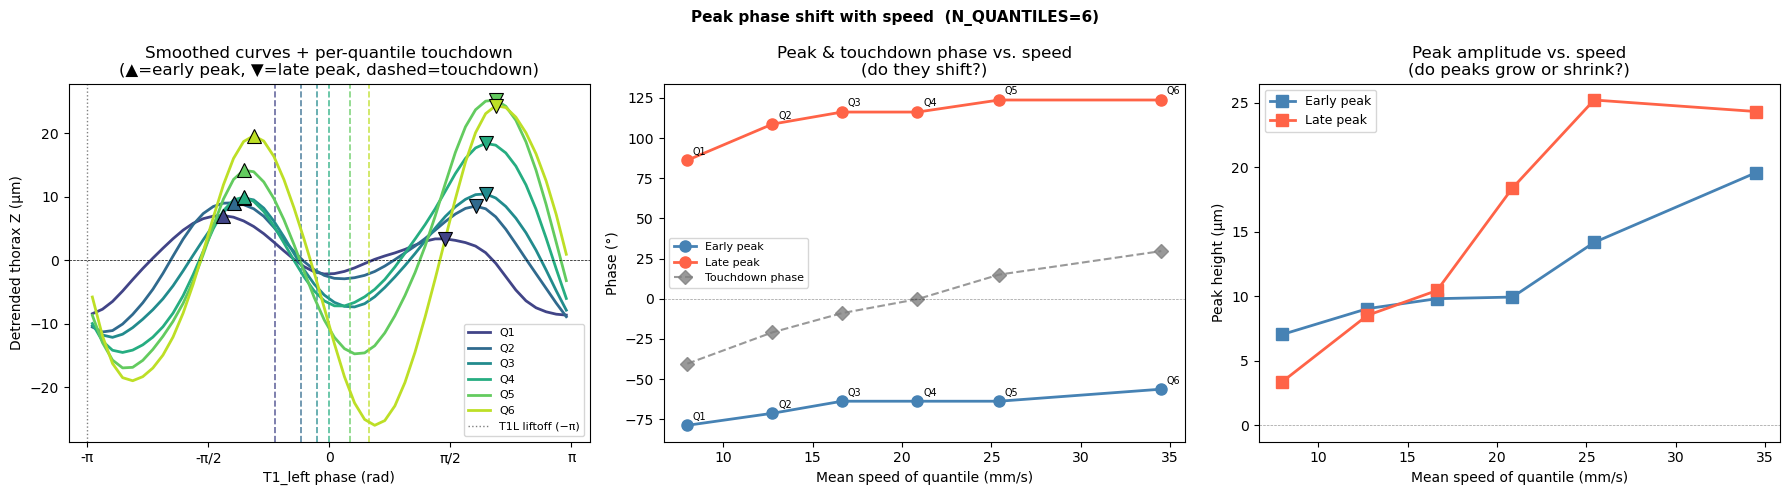

In [5]:
### Cell H2c — Peak phase shift with speed

# Requires H2 to have run (provides _z_phase_q_stored, bin_centers, _mean_speed_per_q,
#  N_BINS, N_QUANTILES, colors_q, mean_td_phase, OUTPUT_DIR)

from scipy.signal import find_peaks
from scipy.stats import spearmanr, linregress

# ── Per-quantile mean touchdown phase ─────────────────────────────────────────
# Touchdown = swing→stance transition (T1_left_swing_stance 0→1)
_td_phase_per_q = {}
for qi, qlabel in enumerate(df_valid.groupby('_sq', observed=True).groups.keys()):
    _td_list = []
    q_mask = df_valid['_sq'] == qlabel
    for _bid, _grp in df_valid[q_mask].groupby('bout_id', sort=False):
        if 'T1_left_swing_stance' not in _grp.columns:
            continue
        _ss = _grp['T1_left_swing_stance'].values.astype(int)
        _ph = _grp['T1_left_phase'].values
        _td_frames = np.where(np.diff(_ss, prepend=_ss[0]) == 1)[0]
        for _tf in _td_frames:
            if _tf < len(_ph) and not np.isnan(_ph[_tf]):
                _td_list.append(_ph[_tf])
    if _td_list:
        _td_phase_per_q[qlabel] = circmean(_td_list, high=np.pi, low=-np.pi)
        print(f"  [{qlabel}] mean touchdown phase: "
              f"{_td_phase_per_q[qlabel]:.3f} rad  "
              f"({np.degrees(_td_phase_per_q[qlabel]):.1f}°)  "
              f"(n={len(_td_list)} touchdowns)")

# ── Find top-2 peaks in each quantile's mean phase curve ─────────────────────
PEAK_SMOOTH_SIGMA    = 1.5   # Gaussian smoothing before peak detection (bins)
PEAK_MIN_DISTANCE    = 8     # minimum bins between peaks
PEAK_MIN_PROMINENCE  = 0.5   # µm — ignore tiny wiggles below this

peak_records = []
_smoothed_q  = {}

quantile_order = list(df_valid.groupby('_sq', observed=True).groups.keys())

for qi, qlabel in enumerate(quantile_order):
    curve = _z_phase_q_stored.get(qlabel)
    if curve is None or np.all(np.isnan(curve)):
        continue

    # Wrap-around smoothing so peaks near ±π aren't clipped at boundary
    pad = N_BINS // 4
    padded = np.concatenate([curve[-pad:], curve, curve[:pad]])
    smoothed_padded = gaussian_filter1d(np.nan_to_num(padded, nan=0.0), PEAK_SMOOTH_SIGMA)
    smoothed = smoothed_padded[pad: pad + N_BINS]
    _smoothed_q[qlabel] = smoothed

    curve_range = np.nanmax(smoothed) - np.nanmin(smoothed)
    prominence_thr = max(PEAK_MIN_PROMINENCE, 0.10 * curve_range)

    peaks, props = find_peaks(
        smoothed,
        distance=PEAK_MIN_DISTANCE,
        prominence=prominence_thr,
    )

    if len(peaks) == 0:
        print(f"[{qlabel}] No peaks found — skipping")
        continue

    prom_order = np.argsort(props['prominences'])[::-1]
    top_peaks  = sorted(peaks[prom_order[:2]])

    mean_spd = _mean_speed_per_q.get(qlabel, np.nan)

    for pk_rank, pk_bin in enumerate(top_peaks):
        peak_records.append(dict(
            quantile       = qlabel,
            qi             = qi,
            peak_rank      = pk_rank,
            peak_bin       = pk_bin,
            peak_phase     = bin_centers[pk_bin],
            peak_phase_deg = np.degrees(bin_centers[pk_bin]),
            peak_height    = smoothed[pk_bin],
            mean_speed     = mean_spd,
        ))

df_peaks = pd.DataFrame(peak_records)
print()
print(df_peaks.to_string(index=False))

# ── Statistical test: Spearman rank correlation speed → peak phase ─────────────
print("\n── Spearman correlation: mean speed vs. peak phase ──")
for rank in [0, 1]:
    sub = df_peaks[df_peaks['peak_rank'] == rank].dropna(subset=['mean_speed', 'peak_phase'])
    if len(sub) < 3:
        print(f"  Peak {'early' if rank==0 else 'late'}: too few points (n={len(sub)})")
        continue
    r, p = spearmanr(sub['mean_speed'], sub['peak_phase'])
    slope, intercept, *_ = linregress(sub['mean_speed'], np.degrees(sub['peak_phase']))
    lbl = 'early' if rank == 0 else 'late'
    print(f"  Peak {lbl}: Spearman r={r:.3f}, p={p:.4f}  |  "
          f"OLS slope={slope:.2f} deg/(mm/s)  (n={len(sub)} quantiles)")

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: smoothed curves with detected peaks + per-quantile touchdown phases
for qi, qlabel in enumerate(quantile_order):
    if qlabel not in _smoothed_q:
        continue
    smoothed = _smoothed_q[qlabel]
    color = colors_q[qi]

    axes[0].plot(bin_centers, smoothed, color=color, lw=2, label=qlabel)

    # Per-quantile touchdown phase (dashed vertical line, same color)
    if qlabel in _td_phase_per_q:
        axes[0].axvline(_td_phase_per_q[qlabel], color=color,
                        ls='--', lw=1.2, alpha=0.8)

    # Peak markers
    pk_sub = df_peaks[df_peaks['quantile'] == qlabel]
    for _, row in pk_sub.iterrows():
        marker = '^' if row['peak_rank'] == 0 else 'v'
        axes[0].plot(row['peak_phase'], row['peak_height'],
                     marker=marker, ms=10, color=color,
                     markeredgecolor='k', markeredgewidth=0.8, zorder=5)

# Liftoff reference (−π, global)
axes[0].axvline(-np.pi, color='k', ls=':', lw=1, alpha=0.5, label='T1L liftoff (−π)')
axes[0].axhline(0, color='k', lw=0.5, ls='--')
axes[0].set_xlabel('T1_left phase (rad)')
axes[0].set_ylabel('Detrended thorax Z (µm)')
axes[0].set_title('Smoothed curves + per-quantile touchdown\n'
                  '(▲=early peak, ▼=late peak, dashed=touchdown)')
axes[0].set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
axes[0].set_xticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
axes[0].legend(fontsize=8)

# Middle: peak phase vs. mean speed
colors_pk = ['steelblue', 'tomato']
labels_pk = ['Early peak', 'Late peak']
for rank in [0, 1]:
    sub = df_peaks[df_peaks['peak_rank'] == rank].sort_values('mean_speed')
    if sub.empty:
        continue
    axes[1].plot(sub['mean_speed'], np.degrees(sub['peak_phase']),
                 'o-', color=colors_pk[rank], lw=2, ms=8, label=labels_pk[rank])
    for _, row in sub.iterrows():
        axes[1].annotate(row['quantile'],
                         (row['mean_speed'], np.degrees(row['peak_phase'])),
                         textcoords='offset points', xytext=(4, 4), fontsize=7)

# Also plot touchdown phase vs. speed
_td_spd   = [_mean_speed_per_q[q] for q in quantile_order if q in _td_phase_per_q]
_td_ph_deg = [np.degrees(_td_phase_per_q[q]) for q in quantile_order if q in _td_phase_per_q]
if _td_spd:
    axes[1].plot(_td_spd, _td_ph_deg, 'D--', color='gray', lw=1.5, ms=7,
                 label='Touchdown phase', alpha=0.8)

axes[1].set_xlabel('Mean speed of quantile (mm/s)')
axes[1].set_ylabel('Phase (°)')
axes[1].set_title('Peak & touchdown phase vs. speed\n(do they shift?)')
axes[1].legend(fontsize=8)
axes[1].axhline(0, color='k', lw=0.5, ls='--', alpha=0.4)

# Right: peak amplitude vs. mean speed
for rank in [0, 1]:
    sub = df_peaks[df_peaks['peak_rank'] == rank].sort_values('mean_speed')
    if sub.empty:
        continue
    axes[2].plot(sub['mean_speed'], sub['peak_height'],
                 's-', color=colors_pk[rank], lw=2, ms=8, label=labels_pk[rank])

axes[2].axhline(0, color='k', lw=0.5, ls='--', alpha=0.4)
axes[2].set_xlabel('Mean speed of quantile (mm/s)')
axes[2].set_ylabel('Peak height (µm)')
axes[2].set_title('Peak amplitude vs. speed\n(do peaks grow or shrink?)')
axes[2].legend(fontsize=9)

plt.suptitle(f'Peak phase shift with speed  (N_QUANTILES={N_QUANTILES})',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'height_peak_phase_shift.pdf', bbox_inches='tight')
plt.show()


Step cycles analysed: 781  |  flies: 7  |  speed range: 1.6–49.1 mm/s
       stance_ms  swing_ms  total_ms  stance_fraction  stride_freq_hz
count     781.00    781.00    781.00           781.00          781.00
mean       49.29     46.80     96.09             0.50           11.97
std        25.00     13.08     33.58             0.11            6.21
min         5.00      1.25     13.75             0.12            3.51
25%        32.50     41.25     75.00             0.43            9.09
50%        43.75     46.25     90.00             0.49           11.11
75%        58.75     52.50    110.00             0.56           13.33
max       231.25    117.50    285.00             0.97           72.73

── Spearman r  (speed vs. …) ──
  stance duration       r=-0.693  p=1.33e-112
  swing duration        r=-0.492  p=8.58e-49
  cycle duration        r=-0.674  p=1.39e-104
  stance fraction       r=-0.652  p=6.47e-96
  stride frequency      r=+0.674  p=1.39e-104


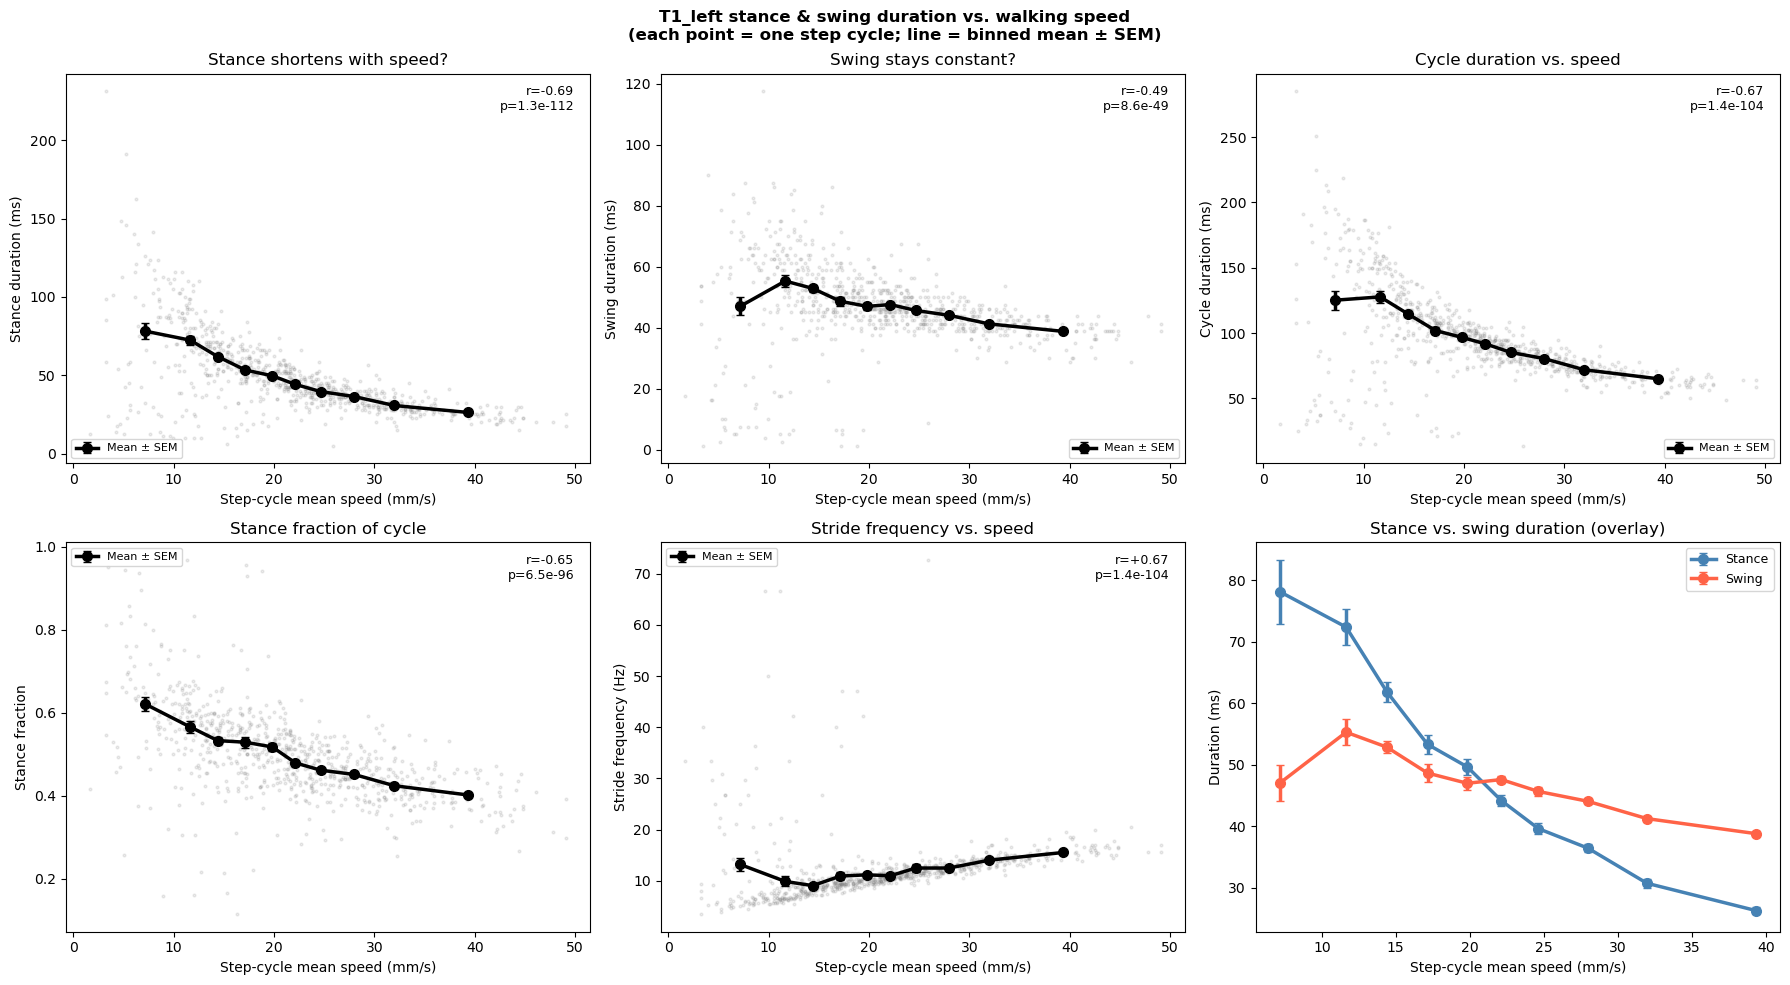

In [6]:
### Cell H2d — Stance & swing duration vs. speed (per step cycle)

# Hypothesis: stance shortens with speed; swing duration stays roughly constant.
# This compresses the stance fraction of the cycle and shifts the effective
# liftoff earlier in time — consistent with what we see in the phase plots.

# ── Per-cycle stance / swing durations ───────────────────────────────────────
_cycle_records = []
for (bid, cid), grp in df_valid.dropna(subset=['step_cycle_id']).groupby(
        ['bout_id', 'step_cycle_id'], sort=False):
    if 'T1_left_swing_stance' not in grp.columns:
        continue
    ss        = grp['T1_left_swing_stance'].values
    n_total   = len(ss)
    n_stance  = int(np.sum(ss == 1))
    n_swing   = int(np.sum(ss == 0))
    mean_spd  = grp['step_cycle_mean_speed'].iloc[0]
    if np.isnan(mean_spd) or n_total < 5:
        continue
    _cycle_records.append(dict(
        bout_id         = bid,
        cycle_id        = cid,
        fly_id          = grp['fly_id'].iloc[0],
        mean_speed      = mean_spd,
        stance_ms       = n_stance  / FPS * 1000,
        swing_ms        = n_swing   / FPS * 1000,
        total_ms        = n_total   / FPS * 1000,
        stance_fraction = n_stance  / n_total,
        stride_freq_hz  = FPS / n_total,
    ))

df_cycle = pd.DataFrame(_cycle_records)
print(f"Step cycles analysed: {len(df_cycle):,}  |  "
      f"flies: {df_cycle['fly_id'].nunique()}  |  "
      f"speed range: {df_cycle['mean_speed'].min():.1f}–"
      f"{df_cycle['mean_speed'].max():.1f} mm/s")
print(df_cycle[['stance_ms','swing_ms','total_ms','stance_fraction','stride_freq_hz']].describe().round(2))

# ── Spearman correlations ─────────────────────────────────────────────────────
from scipy.stats import spearmanr as _sr
print("\n── Spearman r  (speed vs. …) ──")
for col, label in [('stance_ms',       'stance duration'),
                   ('swing_ms',         'swing duration'),
                   ('total_ms',         'cycle duration'),
                   ('stance_fraction',  'stance fraction'),
                   ('stride_freq_hz',   'stride frequency')]:
    r, p = _sr(df_cycle['mean_speed'], df_cycle[col], nan_policy='omit')
    print(f"  {label:<20s}  r={r:+.3f}  p={p:.2e}")

# ── Binned means ± SEM (10 equal-quantile bins) ───────────────────────────────
N_SPD_BINS = 10
_spd_bins  = pd.qcut(df_cycle['mean_speed'], q=N_SPD_BINS)
_spd_ctrs  = df_cycle.groupby(_spd_bins, observed=True)['mean_speed'].mean()

def _binned(col):
    g = df_cycle.groupby(_spd_bins, observed=True)[col]
    return g.mean(), g.sem()

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

scatter_kw = dict(s=4, alpha=0.15, rasterized=True)
line_kw    = dict(lw=2.5, marker='o', ms=7, capsize=3, zorder=5)

# Color per fly
_fly_ids   = sorted(df_cycle['fly_id'].unique())
_fly_colors = {fid: plt.cm.tab10(i) for i, fid in enumerate(_fly_ids)}

panels = [
    ('stance_ms',      'Stance duration (ms)',    'Stance shortens with speed?'),
    ('swing_ms',       'Swing duration (ms)',      'Swing stays constant?'),
    ('total_ms',       'Cycle duration (ms)',      'Cycle duration vs. speed'),
    ('stance_fraction','Stance fraction',          'Stance fraction of cycle'),
    ('stride_freq_hz', 'Stride frequency (Hz)',    'Stride frequency vs. speed'),
]

for ax, (col, ylabel, title) in zip(axes[:5], panels):
    # Raw scatter (gray)
    ax.scatter(df_cycle['mean_speed'], df_cycle[col],
               color='gray', **scatter_kw)
    # Binned mean ± SEM
    mn, se = _binned(col)
    ax.errorbar(_spd_ctrs, mn, yerr=se, color='k', **line_kw, label='Mean ± SEM')
    ax.set_xlabel('Step-cycle mean speed (mm/s)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    r, p = _sr(df_cycle['mean_speed'], df_cycle[col], nan_policy='omit')
    ax.text(0.97, 0.97, f'r={r:+.2f}\np={p:.1e}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(fc='white', ec='none', alpha=0.7))
    ax.legend(fontsize=8)

# Panel 6: stance vs swing on same axis to compare directly
ax6 = axes[5]
mn_st, se_st = _binned('stance_ms')
mn_sw, se_sw = _binned('swing_ms')
ax6.errorbar(_spd_ctrs, mn_st, yerr=se_st, color='steelblue',
             label='Stance', **line_kw)
ax6.errorbar(_spd_ctrs, mn_sw, yerr=se_sw, color='tomato',
             label='Swing',  **line_kw)
ax6.set_xlabel('Step-cycle mean speed (mm/s)')
ax6.set_ylabel('Duration (ms)')
ax6.set_title('Stance vs. swing duration (overlay)')
ax6.legend(fontsize=9)

plt.suptitle('T1_left stance & swing duration vs. walking speed\n'
             '(each point = one step cycle; line = binned mean ± SEM)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'stance_swing_vs_speed.pdf', bbox_inches='tight')
plt.show()


Total step cycles for bootstrap: 781


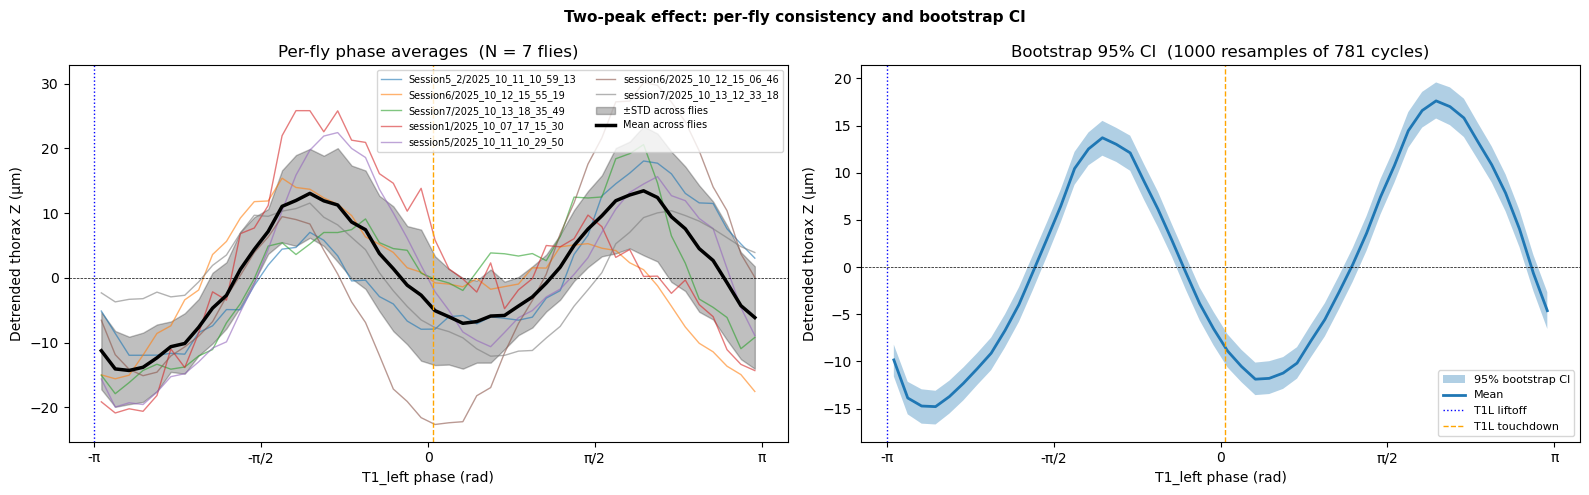


Fourier power by harmonic (mean-across-flies curve):
  Harmonic 1: power = 4853.24
  Harmonic 2: power = 75633.22
  Harmonic 3: power = 109.07
  Harmonic 4: power = 208.83

2nd / 1st harmonic power ratio: 15.58
→ 2nd harmonic dominates: two peaks per stride ✓


In [7]:
### Cell H2b — Two-peak significance: per-fly curves + bootstrap CI

z_um     = df_valid['thorax_z_detrended'].values * 1000   # mm → µm
valid_ph = ~np.isnan(df_valid['T1_left_phase'].values)

# ── Per-fly phase averages ────────────────────────────────────────────────────
fly_ids_sorted = sorted(df_valid['fly_id'].unique())
fly_curves = []
for fid in fly_ids_sorted:
    fly_mask = (df_valid['fly_id'].values == fid) & valid_ph
    curve = np.array([
        z_um[fly_mask & (bin_idx == b)].mean() if (fly_mask & (bin_idx == b)).any() else np.nan
        for b in range(N_BINS)
    ])
    fly_curves.append(curve)
fly_curves = np.array(fly_curves)   # (n_flies, N_BINS)

fly_mean = np.nanmean(fly_curves, axis=0)
fly_std  = np.nanstd(fly_curves,  axis=0)

# ── Bootstrap by step cycle ───────────────────────────────────────────────────
_valid_cycles = df_valid.dropna(subset=['step_cycle_id', 'T1_left_phase'])
cycle_groups  = list(_valid_cycles.groupby(['bout_id', 'step_cycle_id']))
n_cycles      = len(cycle_groups)
print(f"Total step cycles for bootstrap: {n_cycles}")

# Precompute per-cycle phase-bin means  (n_cycles × N_BINS)
cycle_mat = np.full((n_cycles, N_BINS), np.nan)
for i, (_, grp) in enumerate(cycle_groups):
    _b = bin_idx[grp.index]   # phase bin per frame (bin_idx is positional, index is 0-based)
    _z = grp['thorax_z_detrended'].values * 1000
    for b in range(N_BINS):
        vals = _z[_b == b]
        if len(vals) > 0:
            cycle_mat[i, b] = np.nanmean(vals)

N_BOOT = 1000
rng    = np.random.default_rng(42)
boot_means = np.full((N_BOOT, N_BINS), np.nan)
for i in range(N_BOOT):
    idx = rng.integers(0, n_cycles, size=n_cycles)
    boot_means[i] = np.nanmean(cycle_mat[idx], axis=0)

boot_lo = np.nanpercentile(boot_means, 2.5,  axis=0)
boot_hi = np.nanpercentile(boot_means, 97.5, axis=0)
overall_mean = np.nanmean(cycle_mat, axis=0)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: per-fly curves + mean ± STD across flies
colors_fly = plt.cm.tab10(np.linspace(0, 0.7, len(fly_ids_sorted)))
for fi, (fid, curve) in enumerate(zip(fly_ids_sorted, fly_curves)):
    axes[0].plot(bin_centers, curve, color=colors_fly[fi], lw=1, alpha=0.6, label=fid)
axes[0].fill_between(bin_centers, fly_mean - fly_std, fly_mean + fly_std,
                     alpha=0.25, color='k', label='±STD across flies')
axes[0].plot(bin_centers, fly_mean, 'k-', lw=2.5, label='Mean across flies')
axes[0].axhline(0, color='k', lw=0.5, ls='--')
axes[0].axvline(-np.pi, color='blue', ls=':', lw=1)
if mean_td_phase is not None:
    axes[0].axvline(mean_td_phase, color='orange', ls='--', lw=1)
axes[0].set_xlabel('T1_left phase (rad)'); axes[0].set_ylabel('Detrended thorax Z (µm)')
axes[0].set_title(f'Per-fly phase averages  (N = {len(fly_ids_sorted)} flies)')
axes[0].set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
axes[0].set_xticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
axes[0].legend(fontsize=7, ncol=2)

# Right: bootstrap 95% CI (resampled over step cycles)
axes[1].fill_between(bin_centers, boot_lo, boot_hi, alpha=0.35, label='95% bootstrap CI')
axes[1].plot(bin_centers, overall_mean, lw=2, label='Mean')
axes[1].axhline(0, color='k', lw=0.5, ls='--')
axes[1].axvline(-np.pi, color='blue', ls=':', lw=1, label='T1L liftoff')
if mean_td_phase is not None:
    axes[1].axvline(mean_td_phase, color='orange', ls='--', lw=1, label='T1L touchdown')
axes[1].set_xlabel('T1_left phase (rad)'); axes[1].set_ylabel('Detrended thorax Z (µm)')
axes[1].set_title(f'Bootstrap 95% CI  ({N_BOOT} resamples of {n_cycles} cycles)')
axes[1].set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
axes[1].set_xticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
axes[1].legend(fontsize=8)

plt.suptitle('Two-peak effect: per-fly consistency and bootstrap CI',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'height_phase_twopeak_significance.pdf', bbox_inches='tight')
plt.show()

# ── Fourier decomposition: 2nd harmonic dominance ─────────────────────────────
fft_coefs = np.fft.rfft(fly_mean)
power     = np.abs(fft_coefs)**2
print(f"\nFourier power by harmonic (mean-across-flies curve):")
for k in range(1, 5):
    print(f"  Harmonic {k}: power = {power[k]:.2f}")
h1, h2 = power[1], power[2]
print(f"\n2nd / 1st harmonic power ratio: {h2/h1:.2f}")
print("→ " + ("2nd harmonic dominates: two peaks per stride ✓"
               if h2 > h1 else "1st harmonic dominates: one peak per stride"))

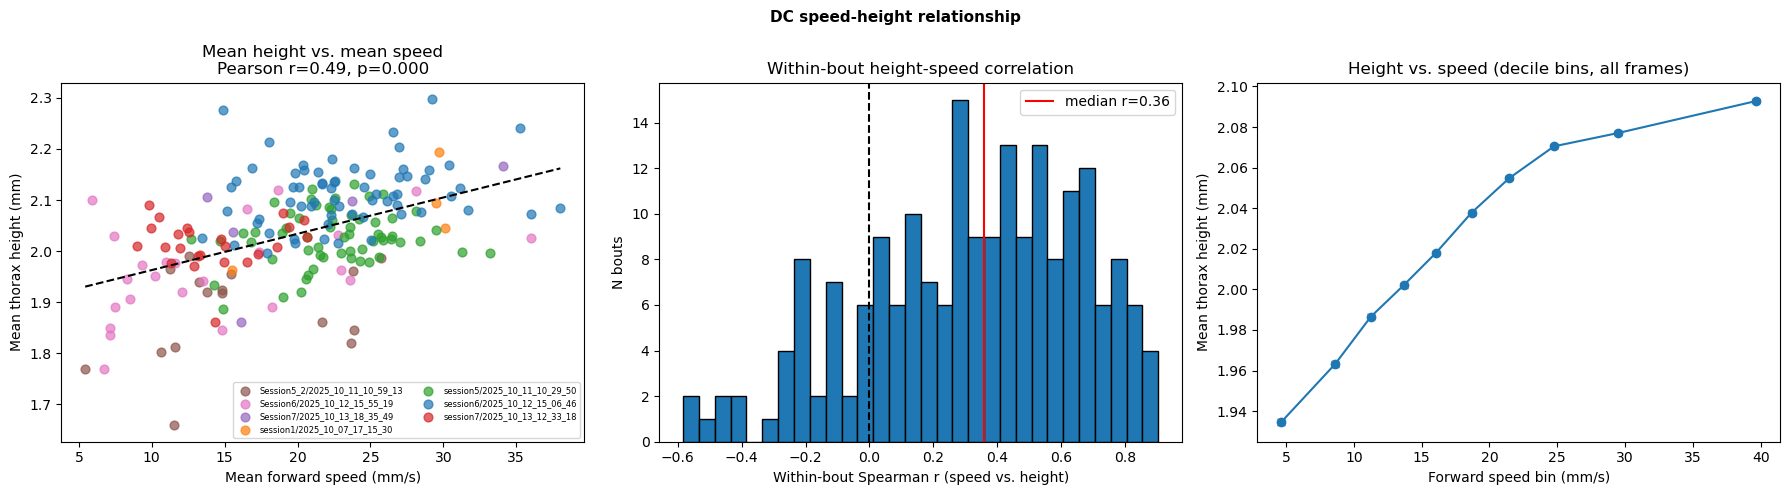

Per-bout Pearson r = 0.490 (p = 0.0000)
Within-bout Spearman r: median = 0.360
→ Faster flies walk higher on average.


In [9]:
### Cell H4 — DC speed-height relationship

bout_stats = df_valid.groupby('bout_id').agg(
    mean_speed=('forward_speed', 'mean'),
    median_speed=('forward_speed', 'median'),
    mean_height=('thorax_z_mm', 'mean'),
    std_height=('thorax_z_mm', 'std'),
    fly_id=('fly_id', 'first'),
).reset_index()
if 'sex' in df_valid.columns:
    bout_stats['sex'] = bout_stats['fly_id'].map(
        df_valid.drop_duplicates('fly_id').set_index('fly_id')['sex'])

r_bout, p_bout = pearsonr(bout_stats['mean_speed'], bout_stats['mean_height'])

r_within = []
for bid, grp in df_valid.groupby('bout_id'):
    if len(grp) < 50: continue
    r, p = spearmanr(grp['forward_speed'], grp['thorax_z_mm'], nan_policy='omit')
    r_within.append({'bout_id': bid, 'r': r, 'p': p,
                     'fly_id': grp['fly_id'].iloc[0],
                     'mean_speed': grp['forward_speed'].mean()})
r_within_df = pd.DataFrame(r_within)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors_fly = {fid: plt.cm.tab10(i) for i, fid in enumerate(bout_stats['fly_id'].unique())}
for fid, grp in bout_stats.groupby('fly_id'):
    axes[0].scatter(grp['mean_speed'], grp['mean_height'],
                    c=[colors_fly[fid]], s=40, alpha=0.7, label=fid)
_xs = np.linspace(bout_stats['mean_speed'].min(), bout_stats['mean_speed'].max(), 100)
_sl, _it = np.polyfit(bout_stats['mean_speed'], bout_stats['mean_height'], 1)
axes[0].plot(_xs, _sl*_xs + _it, 'k--', lw=1.5)
axes[0].set_xlabel('Mean forward speed (mm/s)'); axes[0].set_ylabel('Mean thorax height (mm)')
axes[0].set_title(f'Mean height vs. mean speed\nPearson r={r_bout:.2f}, p={p_bout:.3f}')
axes[0].legend(fontsize=6, ncol=2)

axes[1].hist(r_within_df['r'], bins=30, edgecolor='k')
axes[1].axvline(0, color='k', ls='--')
axes[1].axvline(r_within_df['r'].median(), color='r', ls='-',
                label=f'median r={r_within_df["r"].median():.2f}')
axes[1].set_xlabel('Within-bout Spearman r (speed vs. height)')
axes[1].set_ylabel('N bouts')
axes[1].set_title('Within-bout height-speed correlation')
axes[1].legend()

speed_bins_dc   = pd.qcut(df_valid['forward_speed'], q=10)
height_by_speed = df_valid.groupby(speed_bins_dc, observed=True)['thorax_z_mm'].agg(['mean','sem'])
speed_centers   = df_valid.groupby(speed_bins_dc, observed=True)['forward_speed'].mean()
axes[2].errorbar(speed_centers, height_by_speed['mean'], yerr=height_by_speed['sem'],
                 fmt='o-', capsize=3)
axes[2].set_xlabel('Forward speed bin (mm/s)'); axes[2].set_ylabel('Mean thorax height (mm)')
axes[2].set_title('Height vs. speed (decile bins, all frames)')

plt.suptitle('DC speed-height relationship', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'height_speed_dc.pdf', bbox_inches='tight')
plt.show()

print(f"Per-bout Pearson r = {r_bout:.3f} (p = {p_bout:.4f})")
print(f"Within-bout Spearman r: median = {r_within_df['r'].median():.3f}")
sign = 'higher' if r_bout > 0 else 'lower'
print(f"→ Faster flies walk {sign} on average.")

# Store for summary figure
_speed_centers_dc   = speed_centers.copy()
_height_by_speed_dc = height_by_speed.copy()

/tmp/ipykernel_494855/4291289255.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, fontsize=8)


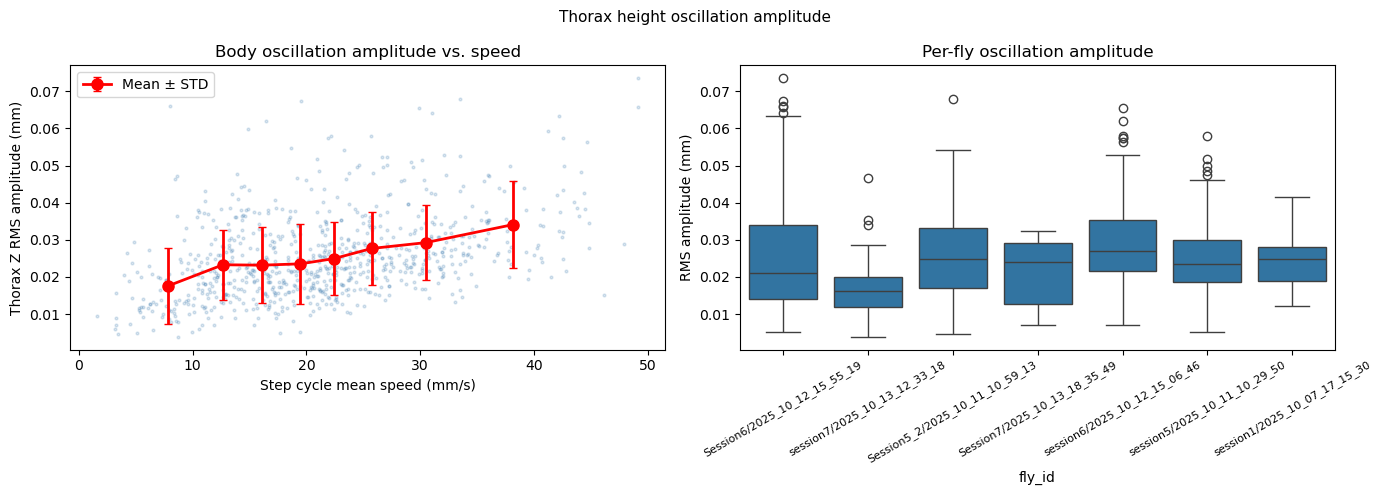

In [11]:
### Cell H6 — Amplitude of oscillation vs. speed

cycle_amp = df_valid.groupby(['bout_id', 'step_cycle_id']).agg(
    speed=('step_cycle_mean_speed', 'first'),
    z_amp=('thorax_z_osc', lambda x: np.sqrt(np.nanmean(x**2))),
    fly_id=('fly_id', 'first'),
).reset_index().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(cycle_amp['speed'], cycle_amp['z_amp'],
                s=4, alpha=0.2, c='steelblue', rasterized=True)
speed_bins_a = pd.qcut(cycle_amp['speed'], q=8)
amp_by_speed = cycle_amp.groupby(speed_bins_a, observed=True)['z_amp'].agg(['mean', 'std'])
spd_c_a      = cycle_amp.groupby(speed_bins_a, observed=True)['speed'].mean()
axes[0].errorbar(spd_c_a, amp_by_speed['mean'], yerr=amp_by_speed['std'],
                 fmt='ro-', lw=2, markersize=8, capsize=3, label='Mean ± STD')
axes[0].set_xlabel('Step cycle mean speed (mm/s)')
axes[0].set_ylabel('Thorax Z RMS amplitude (mm)')
axes[0].set_title('Body oscillation amplitude vs. speed')
axes[0].legend()

fly_order_a = cycle_amp.groupby('fly_id')['speed'].median().sort_values().index.tolist()
sns.boxplot(data=cycle_amp, x='fly_id', y='z_amp', order=fly_order_a, ax=axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, fontsize=8)
axes[1].set_ylabel('RMS amplitude (mm)')
axes[1].set_title('Per-fly oscillation amplitude')

plt.suptitle('Thorax height oscillation amplitude', fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'height_oscillation_amplitude.pdf', bbox_inches='tight')
plt.show()